In [41]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [42]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2,
                  random_state=23)

In [43]:
X.shape

(1000, 2)

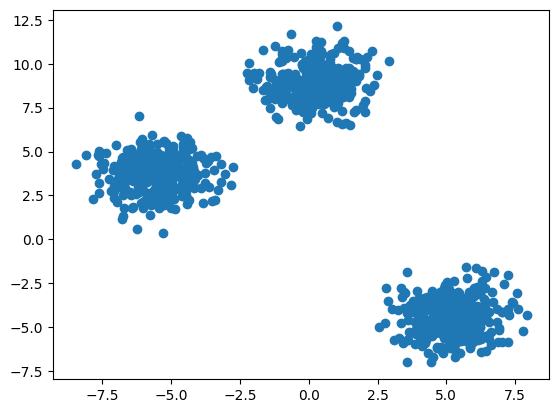

In [44]:
plt.scatter(X[:,0], X[:,1])

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train,y_test = train_test_split(X,y,test_size = 0.33 , random_state= 42)
# Used to divide datasets into parts
#training set - used to train the mode 
# test set - used to evaluate model

In [46]:
from sklearn.cluster import KMeans

In [47]:
#manual way
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [48]:
wcss

[34827.57682552021,
 7935.437286145418,
 1319.2730531585607,
 1140.4677884655125,
 1036.2747709670755,
 892.9445928312239,
 754.9510041821095,
 666.5694107266188,
 582.5473799108406,
 531.277241898362]

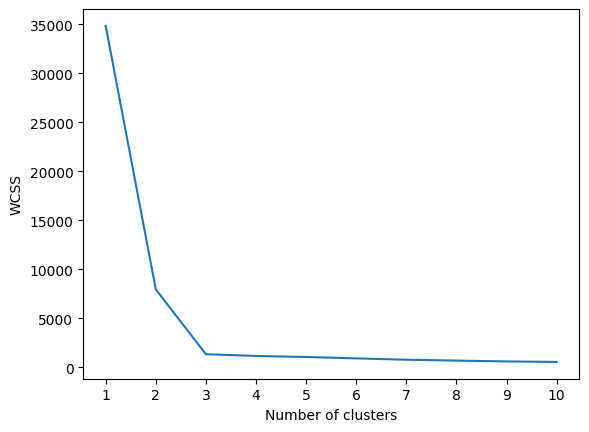

In [49]:
#plot elbow curve 
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel('WCSS')
plt.show()


In [50]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [51]:
y_labels=kmeans.fit_predict(X_train)

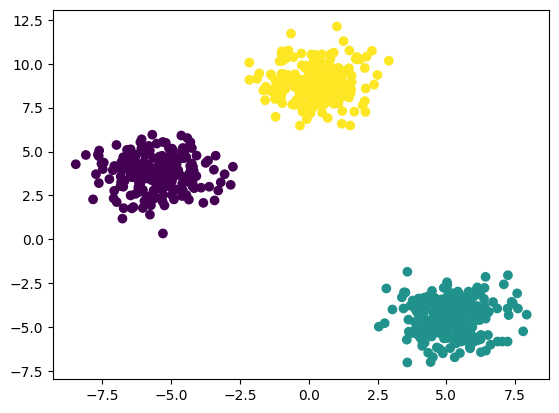

In [52]:
plt.scatter(X_train[:,0], X_train[:,1],c=y_labels)

In [53]:
y_test_label=kmeans.predict(X_test)

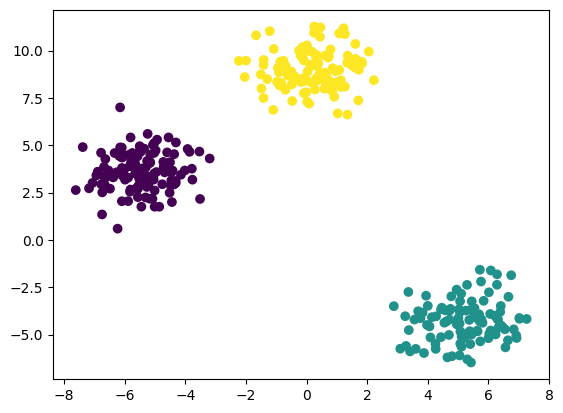

In [54]:
plt.scatter(X_test[:,0], X_test[:,1],c=y_test_label)

In [55]:
#Now Auto K er value find kora - Knee locator
#%pip install kneed

In [56]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [57]:
#perfomance checker - silhoutter scire
from sklearn.metrics import silhouette_score

In [58]:
silo_score=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silo_score.append(score)

In [59]:
silo_score

[0.7281443868598331,
 0.8071181203797672,
 0.6425646103424415,
 0.6321406154444159,
 0.4768174958168632,
 0.3189482708285273,
 0.32318430820800037,
 0.33532581844762505,
 0.3413235855756049]

<function matplotlib.pyplot.show(close=None, block=None)>

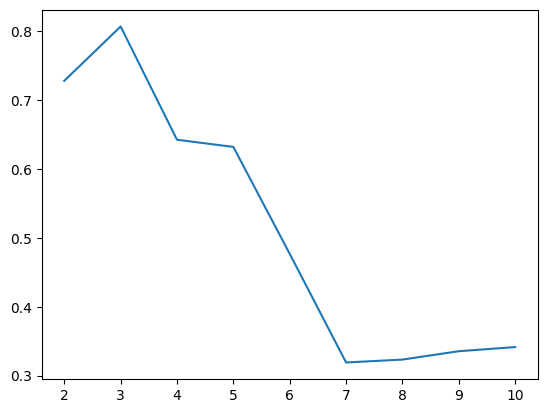

In [60]:
plt.plot(range(2,11),silo_score)
plt.xticks(range(2,11))
plt.show